In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str((Path("..") / "src" / "utils").resolve()))
import micron_comparison

plt.rcParams['svg.fonttype'] = 'none'

In [14]:
with open("../fit_palette.json") as f:
    pal = json.load(f)
BSPBLUE = pal["Piecewise Linear Fit"]

MICRONS_FN_MAT = "/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/data/reimann_data/microns_mm3_connectome.h5"
NBINS = 51             # x-z grid resolution for the Reimann outer-synapse-fraction heuristic
ALPHA_SHAPE = 0.0001    # concaveness of the alpha shape fit to the neuron x-z footprint
REIMANN_THRESH = 0.05  # outer-synapse-fraction cutoff for Reimann's "affected" classification

SCATTER_SIZE, SCATTER_ALPHA, SCATTER_LINEWIDTHS = 0.3, 0.1, 0

SAVE_PDF = "../../result_plots/supplement/microns.pdf"
SAVE_PNG = "../../../bosperrus/rendered_figures/microns.png"

In [5]:
microns_data = micron_comparison.prepare_microns_data(
    MICRONS_FN_MAT, nbins=NBINS, alpha=ALPHA_SHAPE, reimann_thresh=REIMANN_THRESH,
)
micron_comparison.print_comparison_summary(microns_data["comparison"])

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/src/utils/micron_comparison.py:54: RuntimeWarning: invalid value encountered in divide
  C.add_vertex_property("outer_syn_fraction", outer_per_neuron / C.vertices["indegree"].values)
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/src/utils/micron_comparison.py:65: UserWarning: Alpha shape with alpha=0.0001 produced a MultiPolygon (2 disconnected fragments). This usually means alpha is too large: the boundary has been split into pieces, and distances will be measured to the nearest fragment rather than a single enclosing boundary. Consider reducing alpha and inspecting the result visually.
  alpha_distances = bosperrus.distance_to_alpha_shape(coords_xz, alpha=alpha).values


                                 bosperrus  Reimann (neuron)  Reimann (bin)
Neurons affected                    38,777            19,522         36,497
  (% of total)                       65.2%             32.8%          61.4%

Jaccard vs bosperrus
  Reimann per-neuron : 0.500
  Reimann per-bin    : 0.831


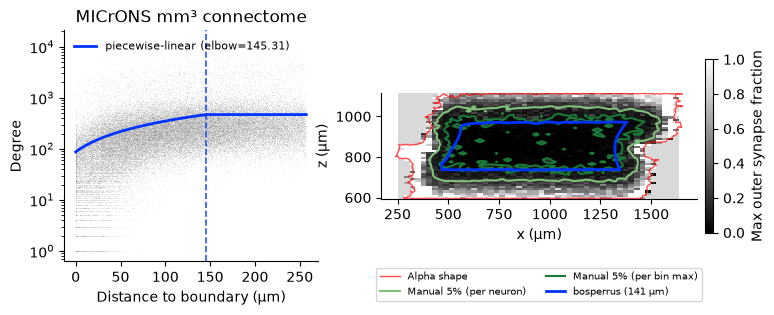

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3), width_ratios=[2, 3])

micron_comparison.plot_fits_panel(
    axs[0],
    microns_data["flow"],
    microns_data["alpha_distances"],
    microns_data["scores"],
    measure="degree",
    scatter_color="gray",
    fit_color=BSPBLUE,
    legend_label_fn=lambda measure, b, m, c: f"piecewise-linear (elbow={b/1e3:.2f})",
    ylabel="Degree",
    title="MICrONS mm³ connectome",
    scatter_size=SCATTER_SIZE, scatter_alpha=SCATTER_ALPHA, scatter_linewidths=SCATTER_LINEWIDTHS,
)

micron_comparison.plot_boundary_heatmap_panel(
    axs[1], microns_data,
    reimann_thresh=REIMANN_THRESH,
    cmap="gray",
    boundary_label="Alpha shape", boundary_color="red",
    reimann_neuron_label="Manual 5% (per neuron)", reimann_neuron_color="#7FBF7B",
    reimann_bin_label="Manual 5% (per bin max)", reimann_bin_color="#1B7837",
    elbow_color=BSPBLUE,
    legend_bbox_to_anchor=(0.5, -0.65),
)

os.makedirs(os.path.dirname(SAVE_PDF), exist_ok=True)
fig.savefig(SAVE_PDF, bbox_inches="tight")
fig.savefig(SAVE_PNG, bbox_inches="tight")


plt.show()